In [2]:
import numpy as np
from qiskit_aer import AerSimulator

backend = AerSimulator()

print(backend.name)

aer_simulator


>>> Observable: ['IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII',
 'ZZIIIIII']
>>> Parameters: ParameterView([Parameter(A), ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])


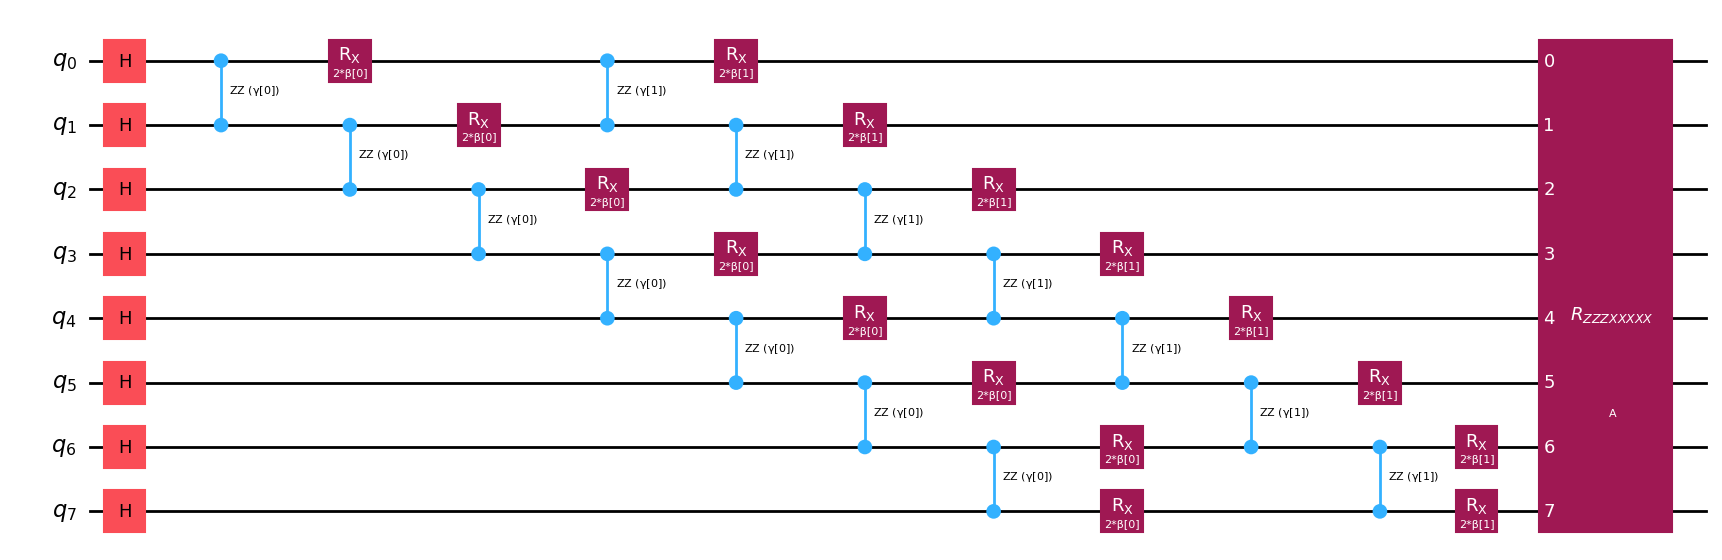

In [31]:
from qiskit.circuit.library import qaoa_ansatz, PauliEvolutionGate
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from itertools import product
num_qubits = 8
entanglement = [tuple(edge) for edge in zip(range(num_qubits-1), range(1,num_qubits))]
observable = SparsePauliOp.from_sparse_list(
    [("ZZ", [i, j], 0.5) for i, j in entanglement]#+[("ZZ", [2,4], 0.5)]
    ,
    num_qubits=num_qubits,
)
circuit = qaoa_ansatz(observable, reps=2)
# the circuit is parametrized, so we will define the parameter values for execution
param_values = [0.1, 0.2, 0.3, 0.4]
pauli_strings = ["".join(tu) for tu in product(*(["XYZI"]*8))]
pauli_gates = [PauliEvolutionGate(SparsePauliOp(pauli_string, 0.5),Parameter("A"), label="$R_{"+pauli_string[::-1]+"}$") for pauli_string in pauli_strings]
circuit.append(pauli_gates[42],list(range(8)))
print(f">>> Observable: {observable.paulis}")
print(f">>> Parameters: {circuit.parameters}")

circuit.draw("mpl")

>>> Circuit ops (ISA): OrderedDict({'h': 18, 'rx': 16, 'rzz': 14, 'cx': 14, 'rz': 1})


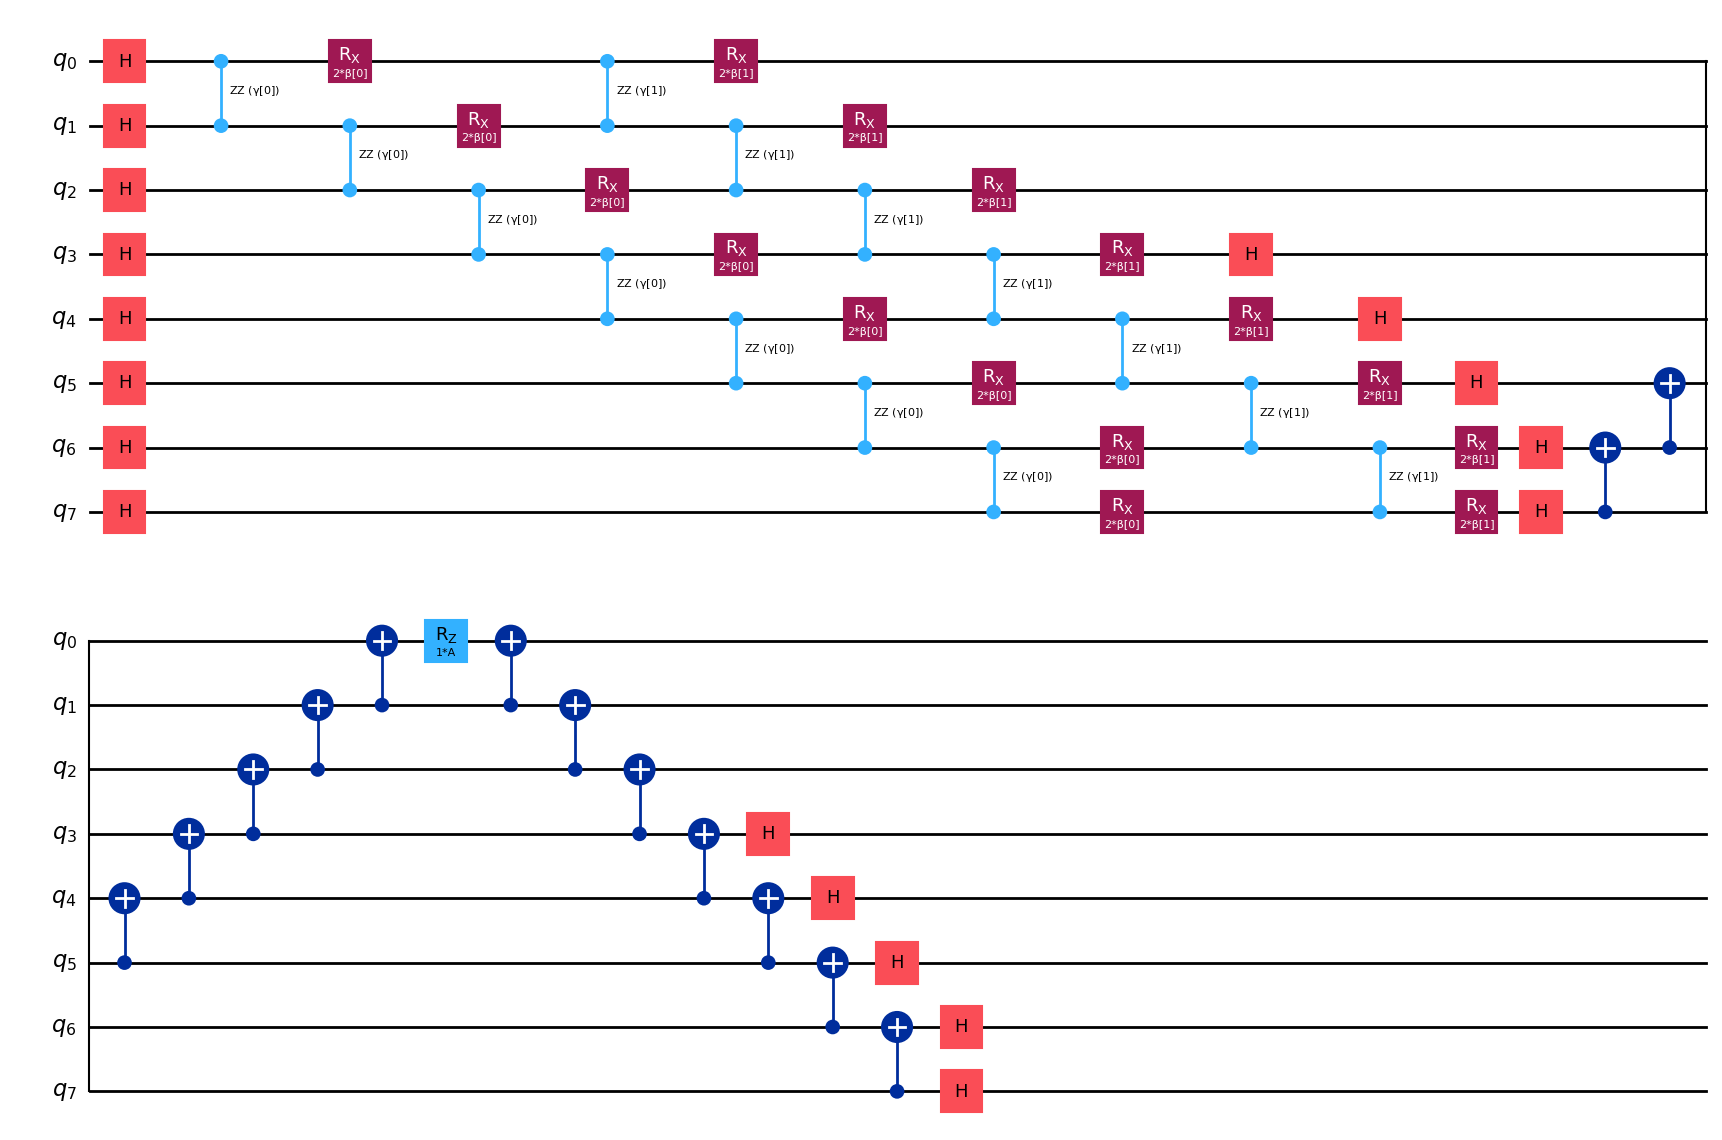

In [32]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
isa_observable = observable.apply_layout(isa_circuit.layout)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")
isa_circuit.draw("mpl")

In [4]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [7]:
job = estimator.run([(isa_circuit, isa_observable, np.array([param_values,param_values]))])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: 2d0c4d95-3380-4b3b-aaf9-d14c349e83bb
>>> Job Status: JobStatus.RUNNING


In [8]:
result = job.result()
print(f">>> {result}")
print(f">>> {result[0]}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(2,), dtype=float64>), stds=np.ndarray(<shape=(2,), dtype=float64>), shape=(2,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
>>> PubResult(data=DataBin(evs=np.ndarray(<shape=(2,), dtype=float64>), stds=np.ndarray(<shape=(2,), dtype=float64>), shape=(2,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})
  > Expectation value: [1.53222656 1.54589844]
  > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}
